## 🧩 Inspiração na Implementação 1D do P-Model

A implementação original do modelo Pmodel em uma dimensão (1D), desenvolvida por **R.R. Rosa, R. Sautter e N. Joshi**, serviu como **inspiração principal** para a extensão do modelo ao domínio bidimensional (2D) com evolução temporal.

Essa versão 1D, adaptada dos trabalhos de **Meneveau & Sreenivasan (1987)**, utiliza um processo de multiplicação estocástica controlado por um parâmetro `p`, responsável por introduzir **intermitência estatística** e **auto-similaridade** em estruturas multifractais. O modelo segue a abordagem original de dividir iterativamente os valores de uma sequência, aplicando flutuações assimétricas, com comportamento guiado pela teoria de **Didier Sornette**.

A lógica central do modelo, baseada na função `next_step_1d`, foi reutilizada e adaptada na implementação 2D para que cada pixel da matriz evolua no tempo como uma série Pmodel, com acoplamento espacial implementado via suavização gaussiana. A função `fractal_spectrum_1d`, embora opcional, também sugere a possibilidade de ajustar o espectro de frequências para simular distribuições com determinadas inclinações espectrais — um recurso que pode ser estendido futuramente para o caso 2D.

Portanto, o modelo 1D serviu como base conceitual e técnica para o desenvolvimento do **modelo Pmodel 2D com evolução temporal**, permitindo gerar campos espaciais sintéticos com características multifractais e dinâmica controlada no tempo.

### 🔗 Referências Técnicas Utilizadas

- Meneveau, C., & Sreenivasan, K. R. (1987). Simple multifractal cascade model for fully developed turbulence. *Physical Review Letters*, 59(13), 1424.


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import norm
import io
import matplotlib.pyplot as plt
import matplotlib.mlab as mlab

import matplotlib as mpl
plt.rcParams["figure.dpi"] = 300
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = ['Times New Roman']

plt.rcParams.update({
    "font.size": 15,       
    "axes.titlesize": 16,  
    "axes.labelsize": 15,  
    "xtick.labelsize": 14, 
    "ytick.labelsize": 14, 
    "legend.fontsize": 12  
})

%matplotlib inline

#XP-model adapted from Meneveau & Sreenevasan, 1987 & Malara et al., 2016
#Valid Ranges for p, based on Didier-Sornette's Theory
#Author: R.R.Rosa, R. Sautter and  N. Joshi
#Version: 1.1
#Date: 23/08/2022

import numpy as np
#import statistics as stat
from matplotlib import pyplot


def pmodel(noValues=1024, p=0.5, slope=[]):
    noOrders = int(np.ceil(np.log2(noValues)))

    dx = np.array([1])
    for n in range(noOrders):
        dx = next_step_1d(dx, p)

    if (slope):
        fourierCoeff = fractal_spectrum_1d(noValues, slope/2)
        meanVal = np.mean(dx)
        stdy = np.std(dx)
        x = np.fft.ifft(dx - meanVal)
        phase = np.angle(x)
        x = fourierCoeff*np.exp(1j*phase)
        x = np.fft.fft(x).real
        x *= stdy/np.std(x)
        x += meanVal
    else:
        x = dx

    return x[0:noValues], dx[0:noValues]


def next_step_1d(dx, p):
    y2 = np.zeros(dx.size*2)
    sign = np.random.rand(1, dx.size) - 0.5
    sign /= np.abs(sign)
    y2[0:2*dx.size:2] = dx + sign*(1-2*p)*dx
    y2[1:2*dx.size+1:2] = dx - sign*(1-2*p)*dx

    return y2


def fractal_spectrum_1d(noValues, slope):
    ori_vector_size = noValues
    ori_half_size = ori_vector_size//2
    a = np.zeros(ori_vector_size)

    for t2 in range(ori_half_size):
        index = t2
        t4 = 1 + ori_vector_size - t2
        if (t4 >= ori_vector_size):
            t4 = t2
        coeff = (index + 1)**slope
        a[t2] = coeff
        a[t4] = coeff

    a[1] = 0

    return a

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = ['Times New Roman']

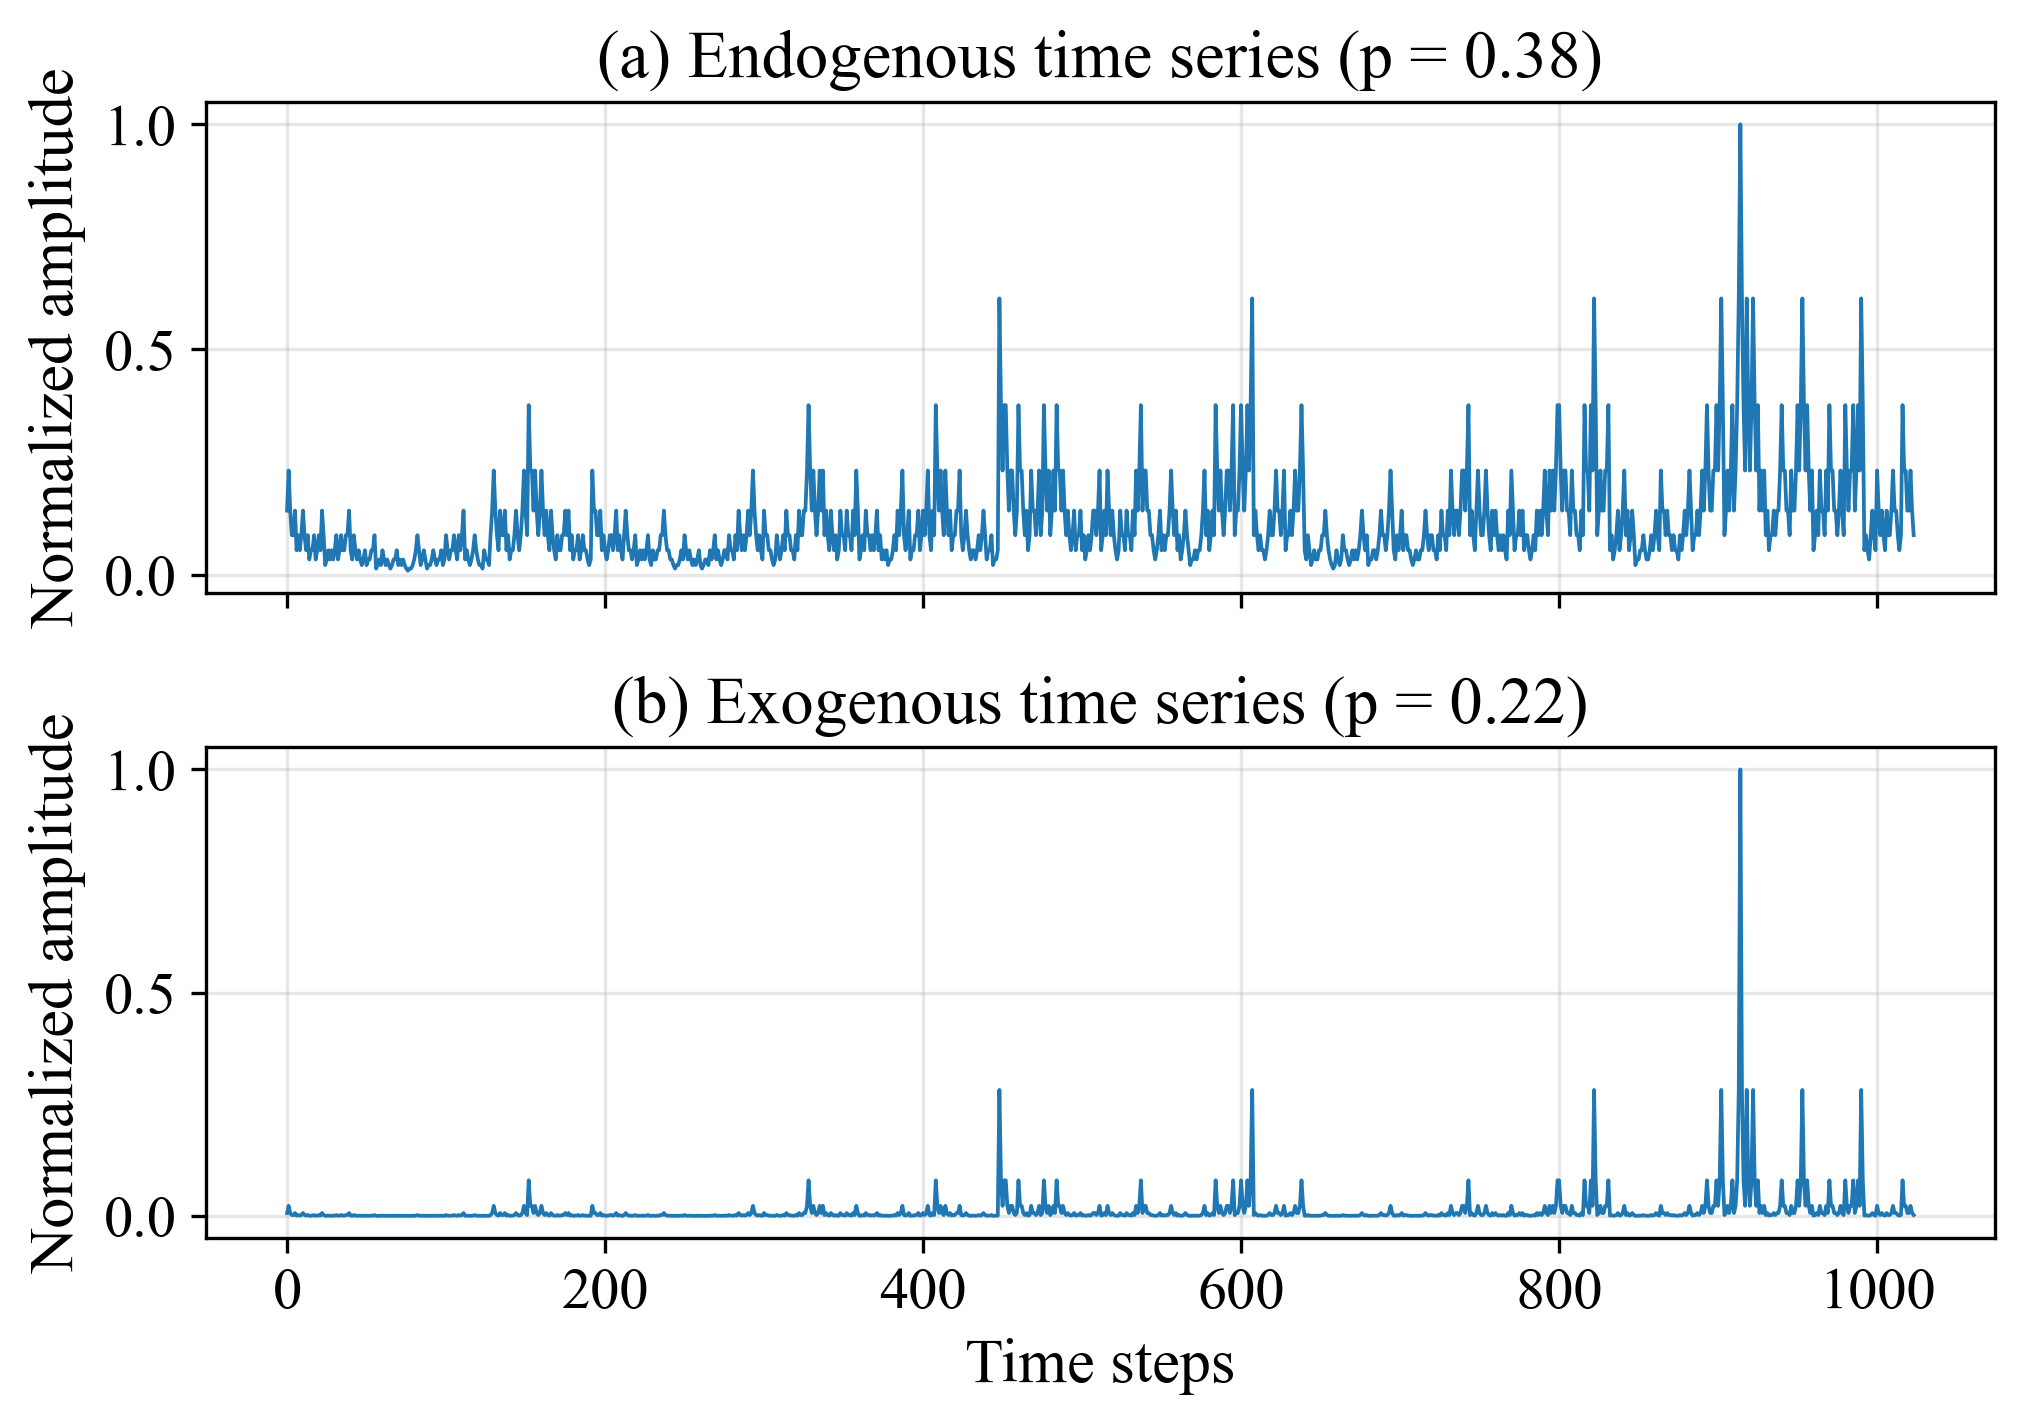

In [7]:
#Endogenous (setup: N, p: 0.32-0.42) 
#Exogenous (setup: N, p: 0.18-0.28)


N = 1024

# Exogenous
p_exo = 0.22
# np.random.seed(126)
np.random.seed(50)
y_exo, dy_exo = pmodel(N, p_exo, 2)

# Endogenous
p_endo = 0.38
# np.random.seed(126)
np.random.seed(50)
y_endo, dy_endo = pmodel(N, p_endo, 2)

def normalize(x):
    x = x + 0.01
    return x / (np.max(x) + 1e-8)

df_exo = normalize(dy_exo)
df_endo = normalize(dy_endo)


fig, axes = plt.subplots(2, 1, figsize=(7, 5), sharex=True)

# ---- Fig. 1a: Endogenous ----
axes[0].plot(df_endo, lw=0.9)
# axes[0].set_ylim(0, 0.4)
axes[0].set_ylabel("Normalized amplitude")
axes[0].set_title("(a) Endogenous time series (p = {:.2f})".format(p_endo))
axes[0].grid(alpha=0.3)

# ---- Fig. 1b: Exogenous ----
axes[1].plot(df_exo, lw=0.9)
# axes[1].set_ylim(0, 0.01)
axes[1].set_xlabel("Time steps")
axes[1].set_ylabel("Normalized amplitude")
axes[1].set_title("(b) Exogenous time series (p = {:.2f})".format(p_exo))
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [61]:
# import numpy as np
# import matplotlib.pyplot as plt

# N = 1024
# num_series = 100
# p = 0.22  # Exemplo: Exogenous
# seeds = np.arange(1, num_series + 1)

# fig, axes = plt.subplots(num_series, 1, figsize=(10, 2*num_series), sharex=True)

# for i, seed in enumerate(seeds):
#     np.random.seed(seed)
#     y, dy = pmodel(N, p, 2)
#     df = normalize(dy)
    
#     axes[i].plot(df, lw=0.8, color='tab:blue')
#     axes[i].set_ylabel(f"Seed {seed}", rotation=0, labelpad=40, fontsize=8)
#     axes[i].set_yticks([])
#     axes[i].grid(alpha=0.3)
    
#     if i == 0:
#         axes[i].set_title(f"Time series (p = {p:.2f})", fontsize=10)

# axes[-1].set_xlabel("Time steps")
# plt.tight_layout()
# plt.show()

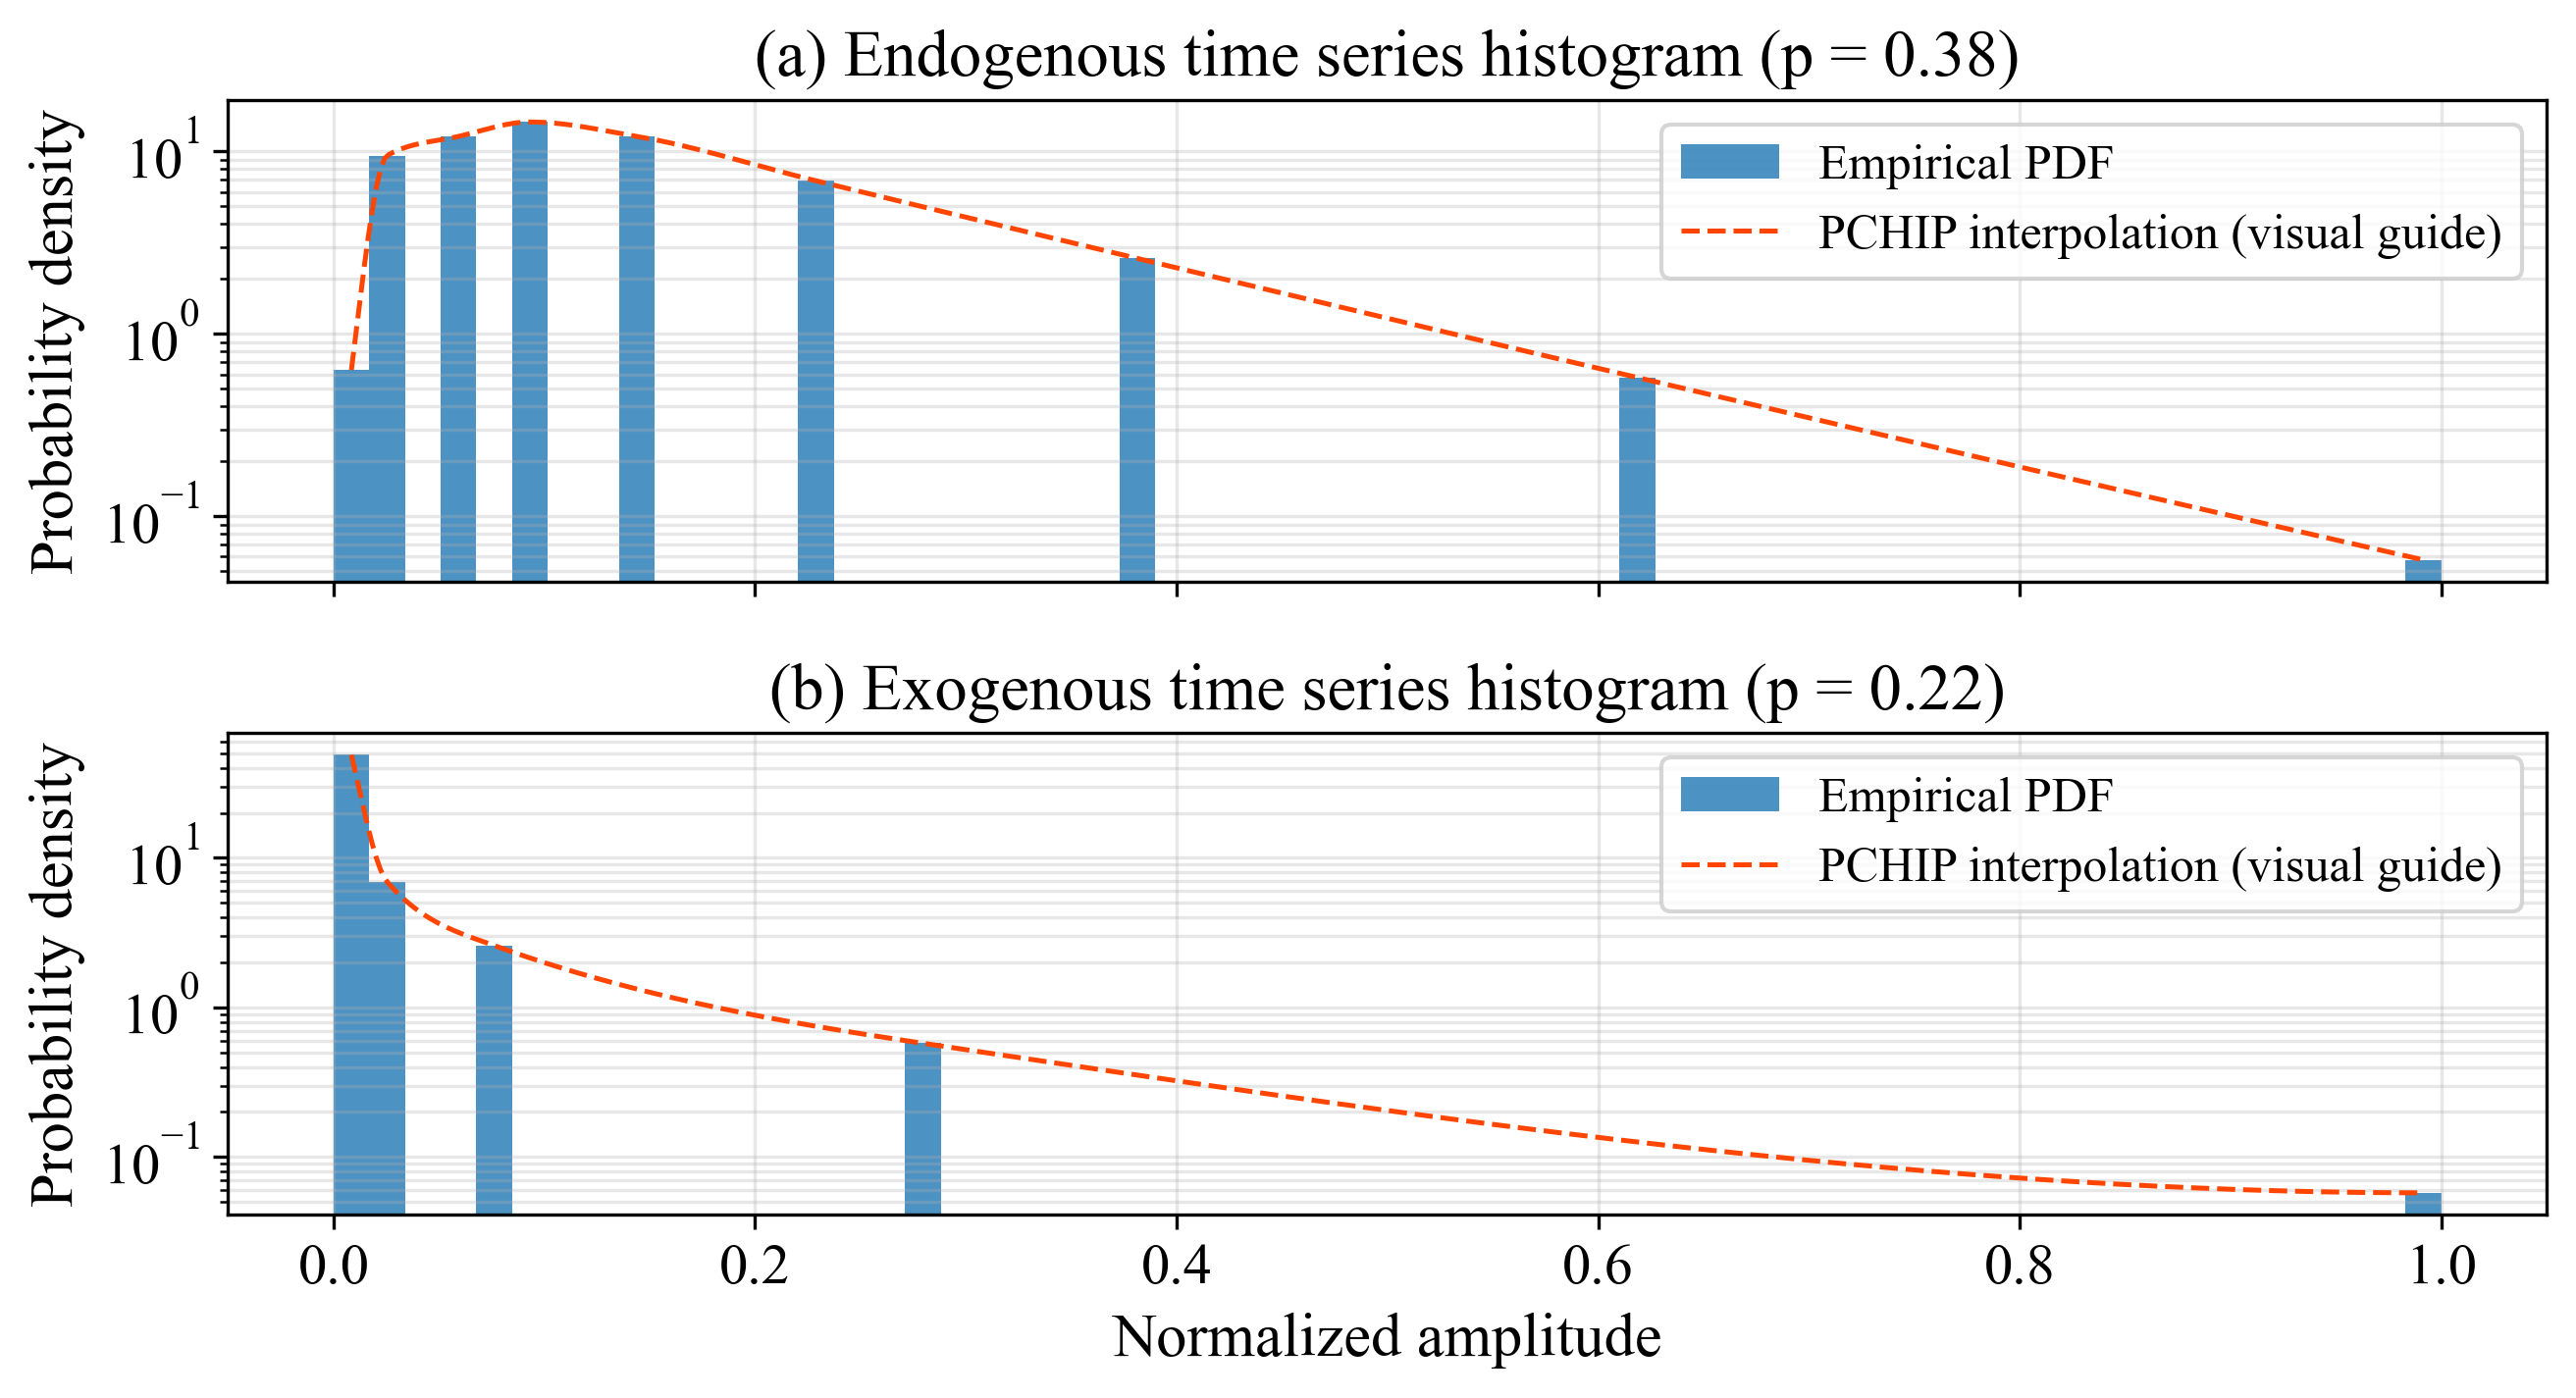

In [8]:
from scipy.interpolate import PchipInterpolator

fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=True)

bins = np.linspace(0, 1, 60)

# Endogenous
hist_endo, bin_edges = np.histogram(df_endo, bins=bins, density=True)
bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
hist_endo[hist_endo == 0] = np.nan

mask = ~np.isnan(hist_endo)
x = bin_centers[mask]
y = hist_endo[mask]

# PCHIP in log-y
pchip_endo = PchipInterpolator(x, np.log(y))

x_fine = np.linspace(x.min(), x.max(), 500)
y_fine = np.exp(pchip_endo(x_fine))

axes[0].hist(
    df_endo,
    bins=bins,
    density=True,
    alpha=0.8,
    label="Empirical PDF"
)
axes[0].plot(x_fine, y_fine, '--', linewidth=1.2, 
label="PCHIP interpolation (visual guide)", color='orangered')

axes[0].set_yscale("log")
axes[0].set_ylabel("Probability density")
axes[0].set_title("(a) Endogenous time series histogram (p = {:.2f})".format(p_endo))
axes[0].grid(alpha=0.3, which="both")
axes[0].legend(frameon=True)



# Exogenous
hist_exo, bin_edges = np.histogram(df_exo, bins=bins, density=True)
bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
hist_exo[hist_exo == 0] = np.nan

mask = ~np.isnan(hist_exo)
x = bin_centers[mask]
y = hist_exo[mask]

# PCHIP in log-y
pchip_exo = PchipInterpolator(x, np.log(y))

x_fine = np.linspace(x.min(), x.max(), 500)
y_fine = np.exp(pchip_exo(x_fine))

axes[1].hist(
    df_exo,
    bins=bins,
    density=True,
    alpha=0.8,
    label="Empirical PDF"
)
axes[1].plot(x_fine, y_fine, '--', linewidth=1.2, 
label="PCHIP interpolation (visual guide)", color='orangered')

axes[1].set_yscale("log")
axes[1].set_xlabel("Normalized amplitude")
axes[1].set_ylabel("Probability density")
axes[1].set_title("(b) Exogenous time series histogram (p = {:.2f})".format(p_exo))
axes[1].grid(alpha=0.3, which="both")
axes[1].legend(frameon=True)


plt.tight_layout()
plt.savefig("../aedeep_pmodel/paper/images/histogram_synthetic_series_p_model_endogenous_exogenous.png", dpi=300, bbox_inches='tight')  
plt.show()


In [27]:
def prepare_series(
    series,
    peak_percentile=99
):
    normalized_series = (
        (series - np.min(series)) /
        (np.max(series) - np.min(series) + 1e-6)
    )

    df = pd.DataFrame({
        "raw": series,
        "normalized": normalized_series
    })

    threshold = np.percentile(df["normalized"], peak_percentile)
    df["peak"] = (df["normalized"] > threshold).astype(int)
    df["peak_threshold"] = threshold

    return df

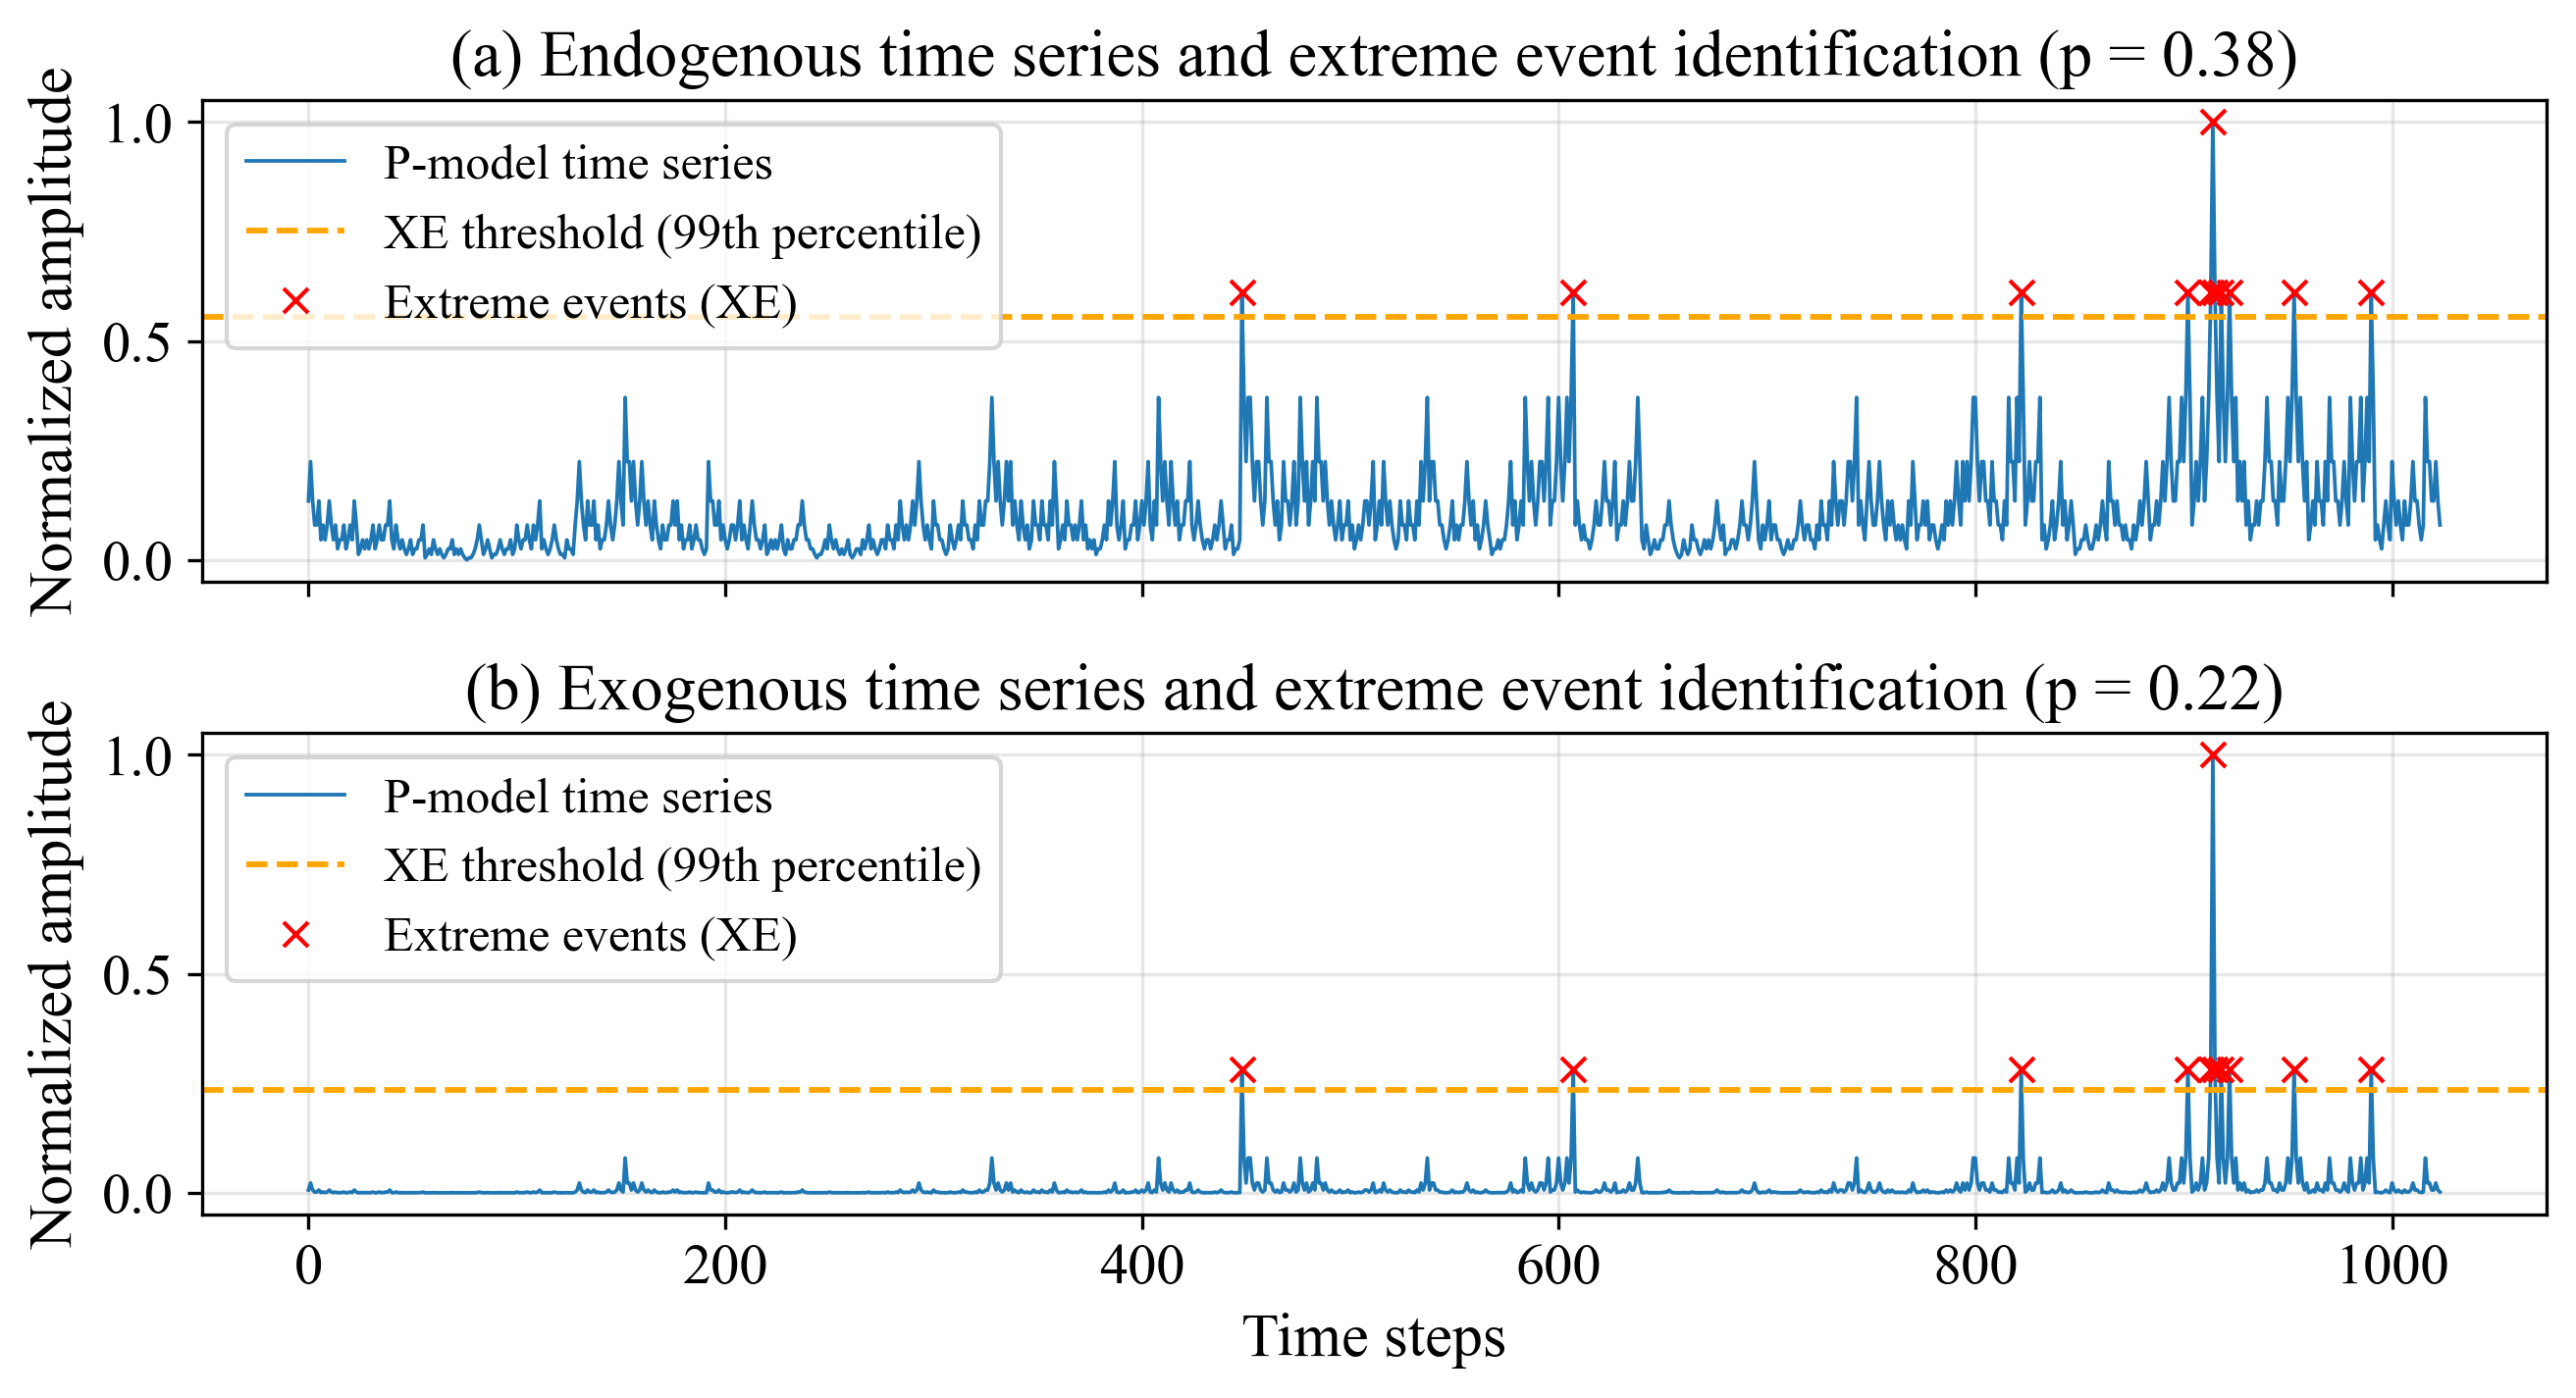

In [105]:
df_endo_peaks = prepare_series(df_endo, peak_percentile=99)
df_exo_peaks  = prepare_series(df_exo,  peak_percentile=99)

fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=True)

# ---------- Endogenous ----------
t_endo = np.arange(len(df_endo_peaks))
theta_endo = df_endo_peaks["peak_threshold"].iloc[0]

axes[0].plot(
    t_endo,
    df_endo_peaks["normalized"],
    lw=0.9,
    label="P-model time series"
)

# Threshold line
axes[0].axhline(
    theta_endo,
    linestyle="--",
    linewidth=1.4,
    label="XE threshold (99th percentile)",
    color="orange"
)

# Peaks
axes[0].plot(
    t_endo[df_endo_peaks["peak"] == 1],
    df_endo_peaks.loc[df_endo_peaks["peak"] == 1, "normalized"],
    "x",
    markersize=6,
    label="Extreme events (XE)",
    color="red"
)

axes[0].set_ylabel("Normalized amplitude")
axes[0].set_title("(a) Endogenous time series and extreme event identification (p = {:.2f})".format(p_endo))
axes[0].grid(alpha=0.3)
axes[0].legend(frameon=True)

# ---------- Exogenous ----------
t_exo = np.arange(len(df_exo_peaks))
theta_exo = df_exo_peaks["peak_threshold"].iloc[0]

axes[1].plot(
    t_exo,
    df_exo_peaks["normalized"],
    lw=0.9,
    label="P-model time series"
)

# Threshold line
axes[1].axhline(
    theta_exo,
    linestyle="--",
    linewidth=1.4,
    label="XE threshold (99th percentile)",
    color="orange"
)

# Peaks
axes[1].plot(
    t_exo[df_exo_peaks["peak"] == 1],
    df_exo_peaks.loc[df_exo_peaks["peak"] == 1, "normalized"],
    "x",
    markersize=6,
    label="Extreme events (XE)",
    color="red"
)

axes[1].set_xlabel("Time steps")
axes[1].set_ylabel("Normalized amplitude")
axes[1].set_title("(b) Exogenous time series and extreme event identification (p = {:.2f})".format(p_exo))
axes[1].grid(alpha=0.3)
axes[1].legend(frameon=True)

plt.tight_layout()
plt.savefig("../aedeep_pmodel/paper/images/synthetic_time_series_p_model_endo_exo_with_peaks.png", dpi=300, bbox_inches='tight')
plt.show()



/var/folders/25/4ts88tzd08500lbfck1y7nn40000gn/T/ipykernel_6749/2094138488.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


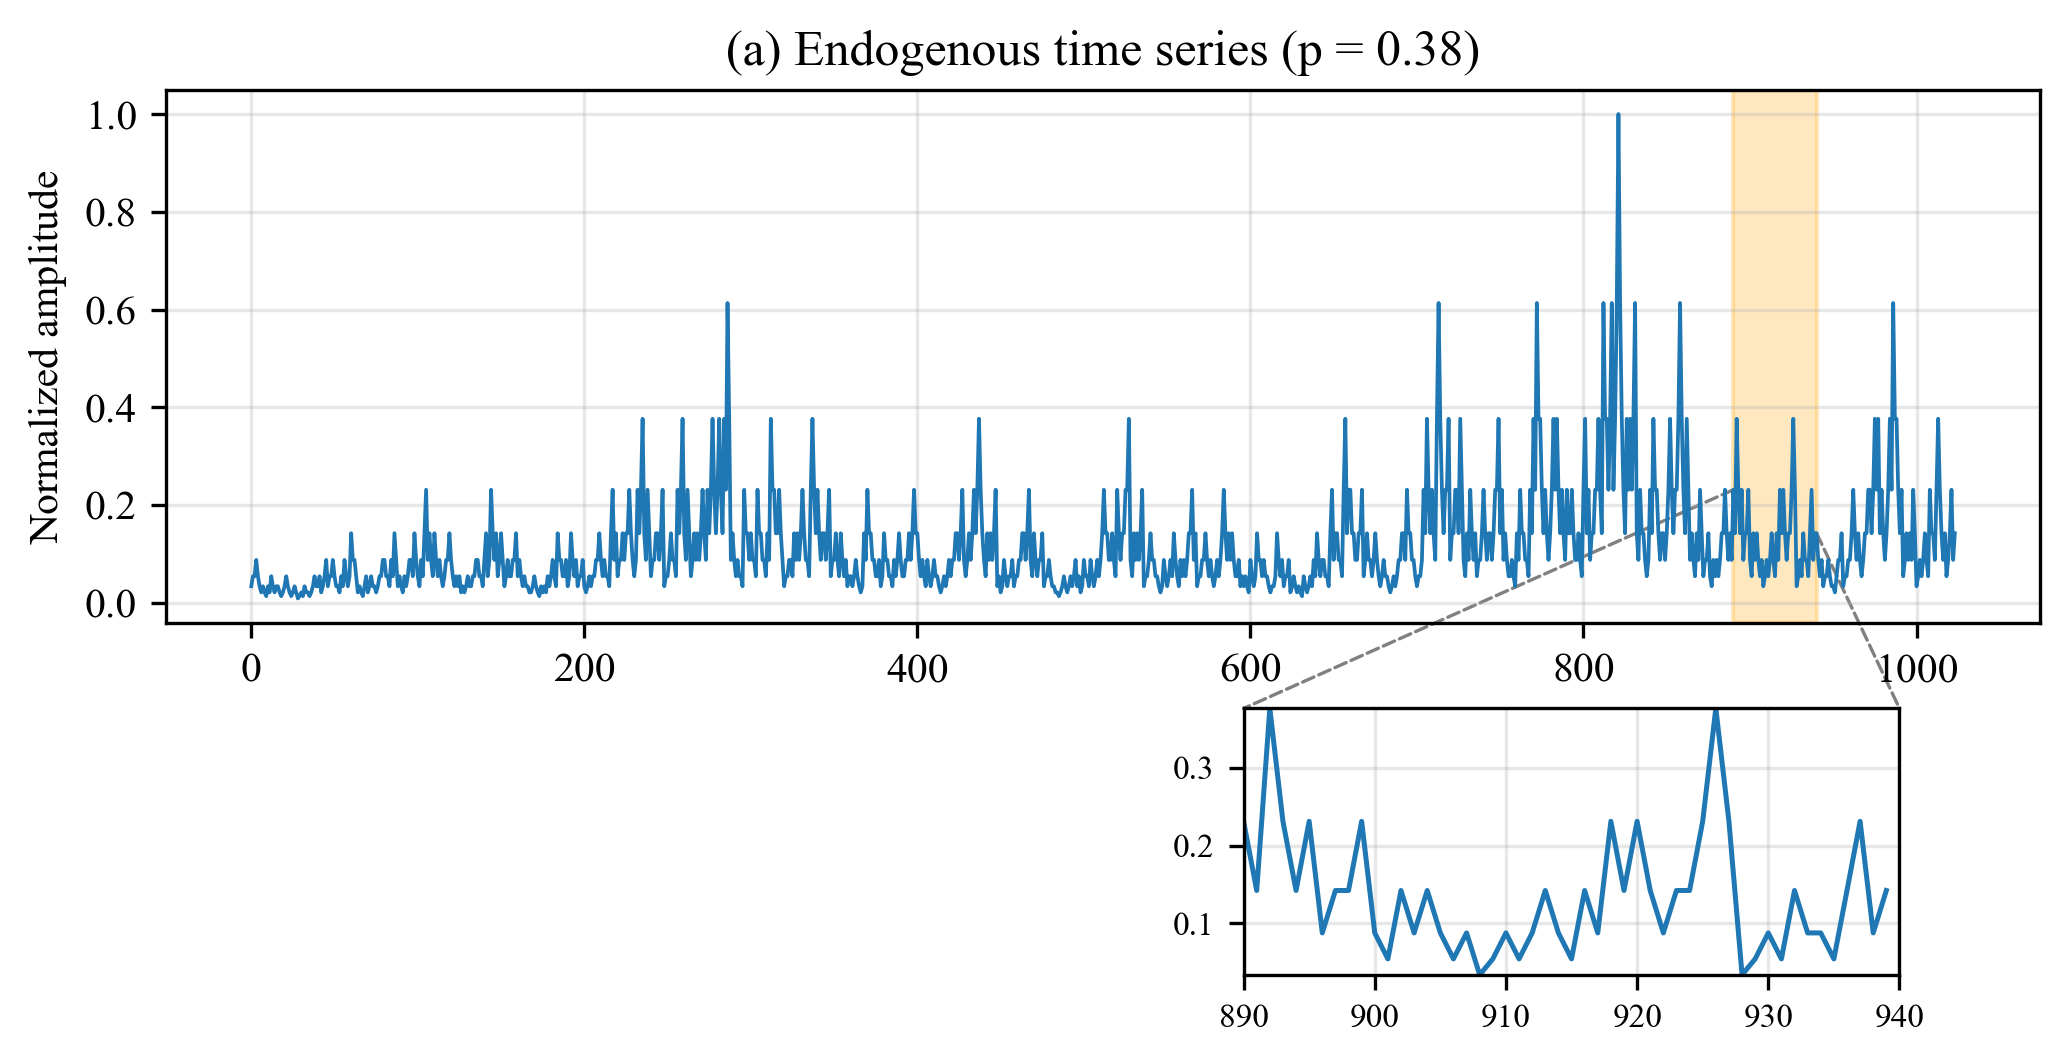

In [29]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

x_ini, x_fim = 890, 940

fig, ax = plt.subplots(figsize=(7, 2.5))

# gráfico principal
ax.plot(df_endo, lw=0.9)

# ax.set_ylim(-1, None)
ax.set_ylabel("Normalized amplitude")
ax.set_title("(a) Endogenous time series (p = {:.2f})".format(p_endo))
ax.grid(alpha=0.3)

# destaca a região no gráfico principal
ax.axvspan(x_ini, x_fim, color="orange", alpha=0.25)

# cria o inset (janela de zoom)
axins = inset_axes(
    ax,
    width="35%",   # largura relativa
    height="50%",  # altura relativa
    loc="lower center",
    bbox_to_anchor=(0.25, -0.7, 1, 1),
    bbox_transform=ax.transAxes
)

# plota apenas a região ampliada
axins.plot(
    range(x_ini, x_fim),
    df_endo[x_ini:x_fim],
    lw=1.2
)

# limites do zoom
axins.set_xlim(x_ini, x_fim)
axins.set_ylim(
    df_endo[x_ini:x_fim].min(),
    df_endo[x_ini:x_fim].max()
)

axins.grid(alpha=0.3)
axins.tick_params(labelsize=8)

# conecta a região ao inset (opcional, mas bonito)
from matplotlib.patches import ConnectionPatch

# canto inferior esquerdo da região no gráfico principal
con1 = ConnectionPatch(
    xyA=(x_ini, df_endo[x_ini]),  # ponto no gráfico principal
    coordsA=ax.transData,
    xyB=(x_ini, axins.get_ylim()[1]),  # topo do inset
    coordsB=axins.transData,
    color="0.5",
    lw=0.8,
    linestyle="--"
)

# canto inferior esquerdo da outra borda
con2 = ConnectionPatch(
    xyA=(x_fim, df_endo[x_fim-1]),
    coordsA=ax.transData,
    xyB=(x_fim, axins.get_ylim()[1]),
    coordsB=axins.transData,
    color="0.5",
    lw=0.8,
    linestyle="--"
)

ax.add_artist(con1)
ax.add_artist(con2)


# 1 ─ upper right
# 2 ─ upper left
# 3 ─ lower left
# 4 ─ lower right

plt.tight_layout()
plt.show()



/var/folders/25/4ts88tzd08500lbfck1y7nn40000gn/T/ipykernel_6749/2344883392.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


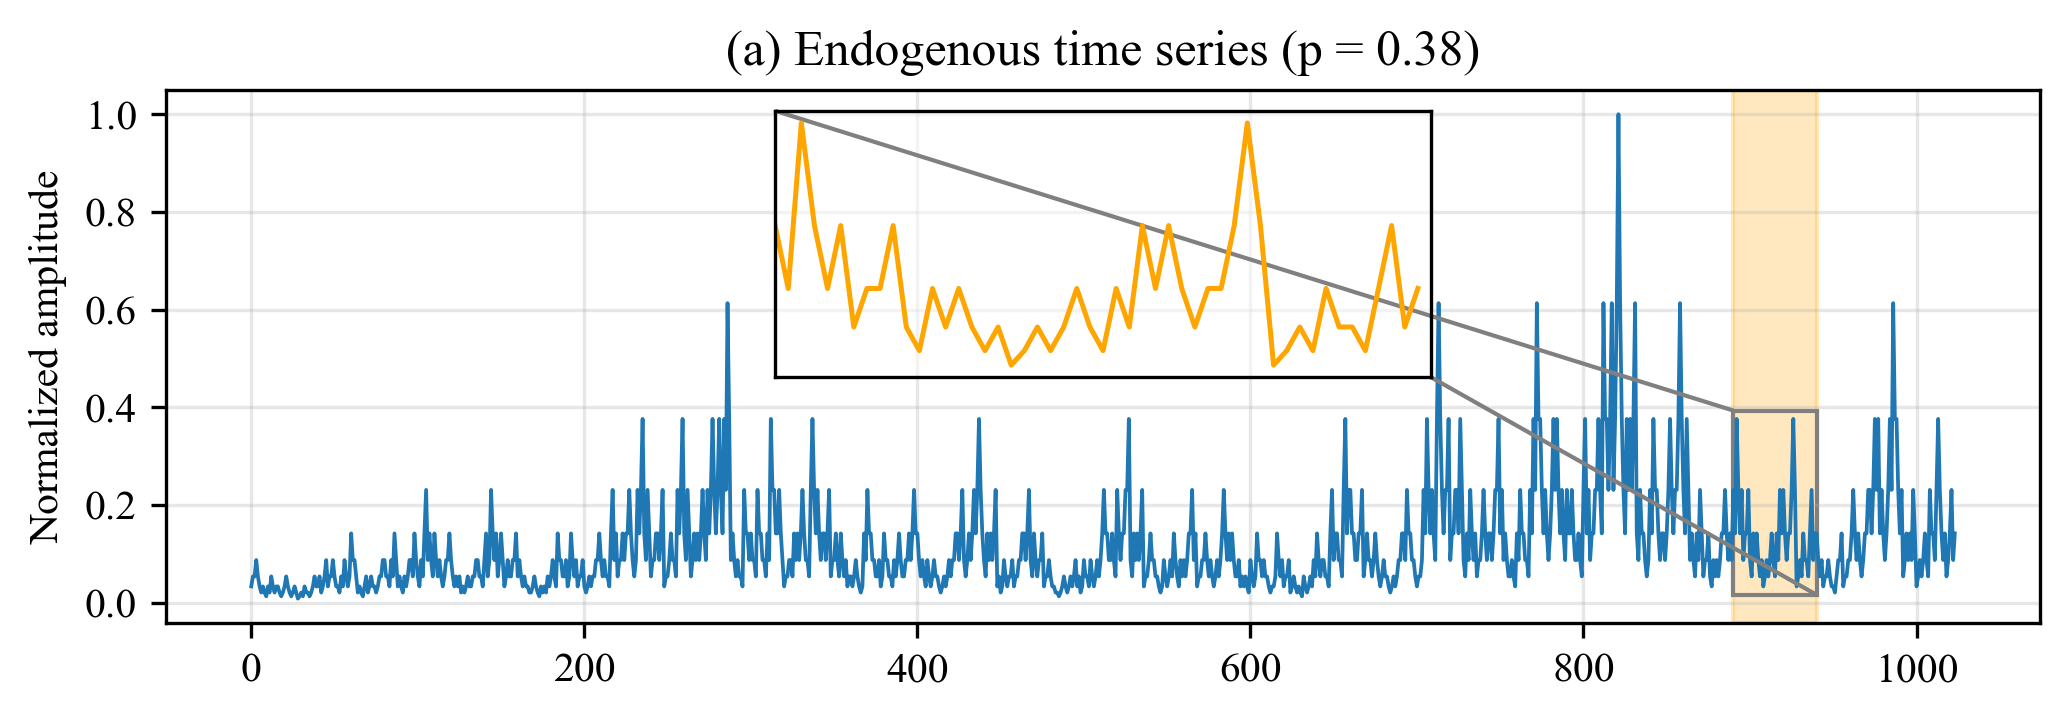

In [30]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

x_ini, x_fim = 890, 940

fig, ax = plt.subplots(figsize=(7, 2.5))

# gráfico principal
ax.plot(df_endo, lw=0.9)

# ax.set_ylim(-1, None)
ax.set_ylabel("Normalized amplitude")
ax.set_title("(a) Endogenous time series (p = {:.2f})".format(p_endo))
ax.grid(alpha=0.3)

# destaca a região no gráfico principal
ax.axvspan(x_ini, x_fim, color="orange", alpha=0.25)

# cria o inset (janela de zoom)
axins = inset_axes(
    ax,
    width="35%",   # largura relativa
    height="50%",  # altura relativa
    loc="upper center",
    # bbox_to_anchor=(0, -0.7, 1, 1),
    # bbox_transform=ax.transAxes
)

# plota apenas a região ampliada
axins.plot(
    range(x_ini, x_fim),
    df_endo[x_ini:x_fim],
    color="orange",
    lw=1.2
)

# limites do zoom
axins.set_xlim(x_ini, x_fim)

axins.grid(alpha=0.3)
axins.tick_params(labelsize=8)

axins.set_xticks([])
axins.set_yticks([])
axins.patch.set_alpha(0.5)

# conecta a região ao inset (opcional, mas bonito)
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5")


plt.tight_layout()
plt.show()



/var/folders/25/4ts88tzd08500lbfck1y7nn40000gn/T/ipykernel_6749/3724377167.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


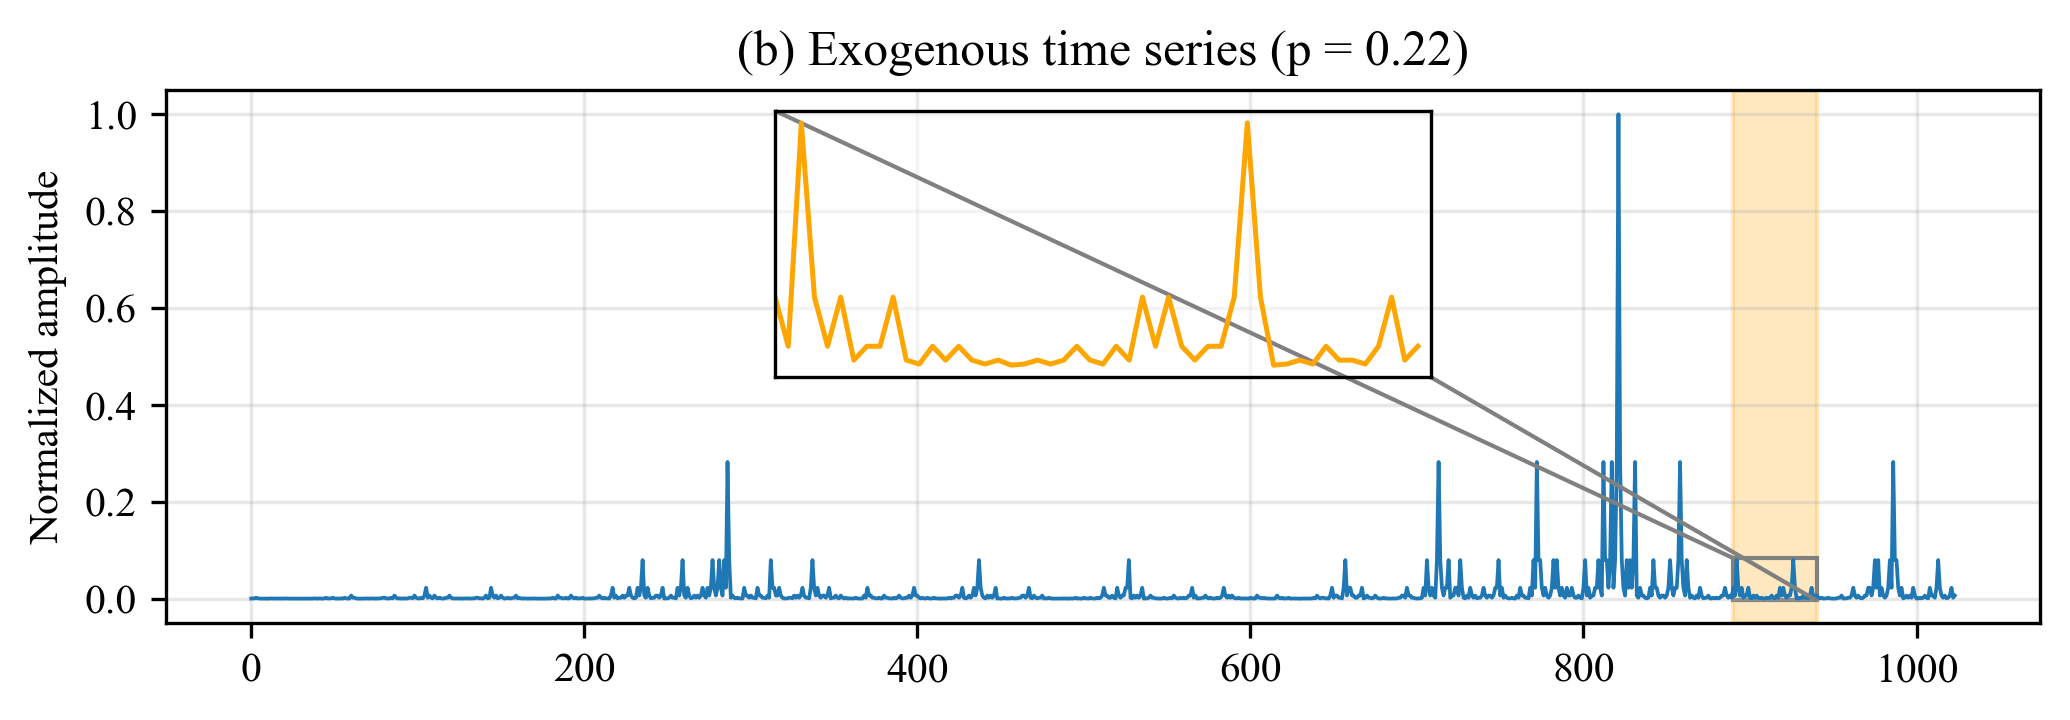

In [31]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

x_ini, x_fim = 890, 940

fig, ax = plt.subplots(figsize=(7, 2.5))

# gráfico principal
ax.plot(df_exo, lw=0.9)

# ax.set_ylim(-1, None)
ax.set_ylabel("Normalized amplitude")
ax.set_title("(b) Exogenous time series (p = {:.2f})".format(p_exo))
ax.grid(alpha=0.3)

# destaca a região no gráfico principal
ax.axvspan(x_ini, x_fim, color="orange", alpha=0.25)

# cria o inset (janela de zoom)
axins = inset_axes(
    ax,
    width="35%",   # largura relativa
    height="50%",  # altura relativa
    loc="upper center",
    # bbox_to_anchor=(0, -0.7, 1, 1),
    # bbox_transform=ax.transAxes
)

# plota apenas a região ampliada
axins.plot(
    range(x_ini, x_fim),
    df_exo[x_ini:x_fim],
    color="orange",
    lw=1.2
)

# limites do zoom
axins.set_xlim(x_ini, x_fim)

axins.grid(alpha=0.3)
axins.tick_params(labelsize=8)

axins.set_xticks([])
axins.set_yticks([])
axins.patch.set_alpha(0.5)

# conecta a região ao inset (opcional, mas bonito)
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5")


plt.tight_layout()
plt.show()



/var/folders/25/4ts88tzd08500lbfck1y7nn40000gn/T/ipykernel_6749/1393505961.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


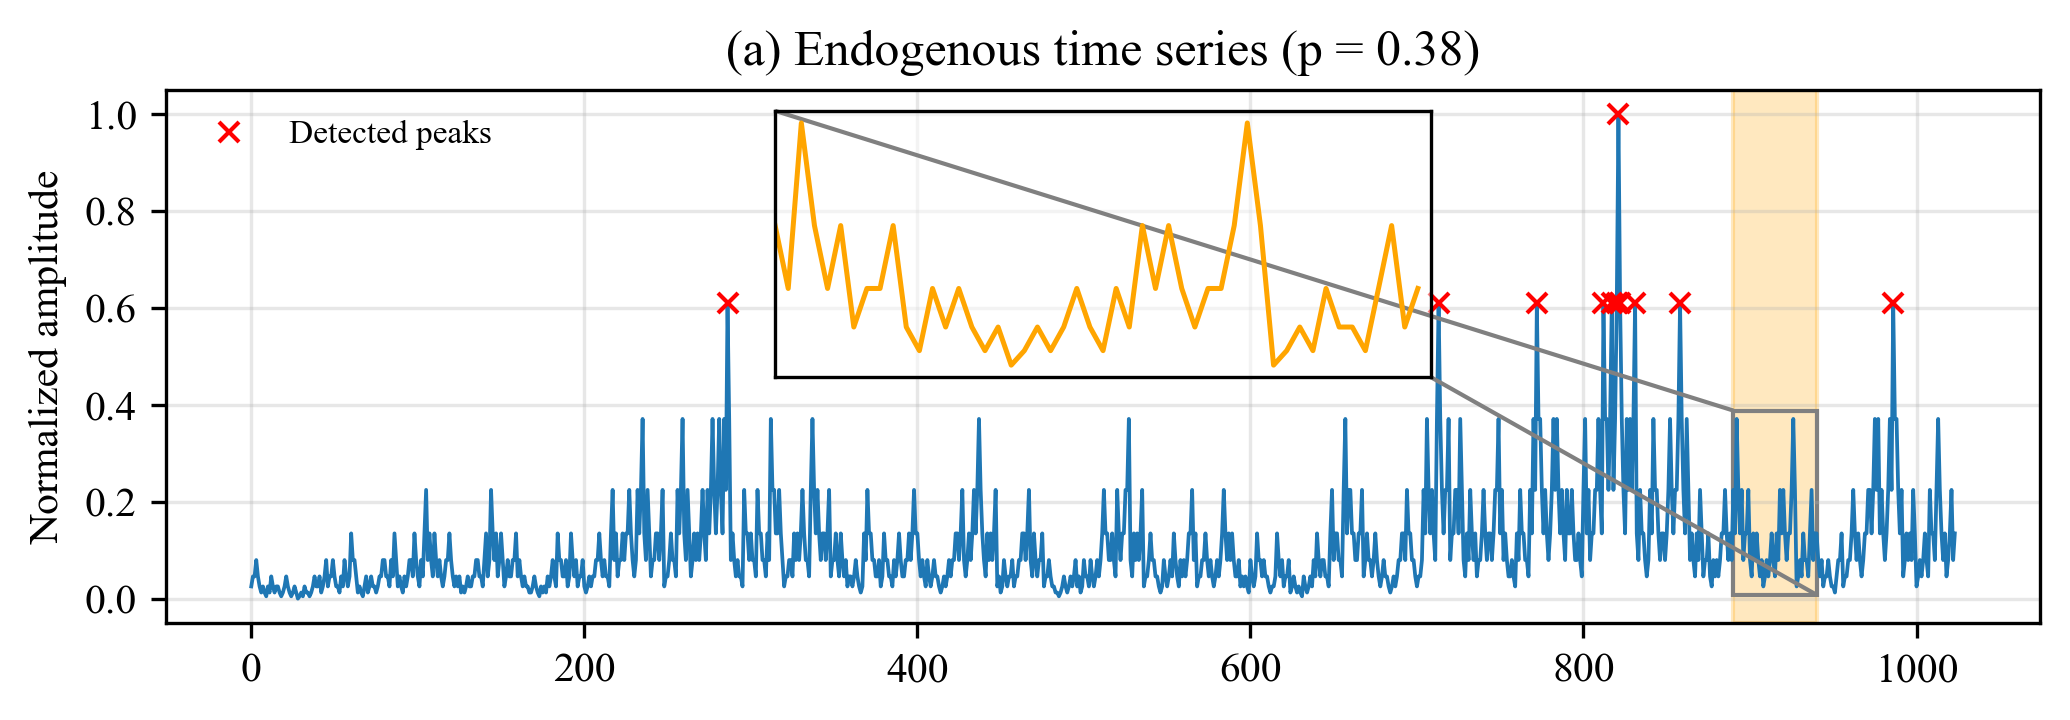

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# -----------------------------
# Preparação dos dados
# -----------------------------
df_endo_peaks = prepare_series(df_endo, peak_percentile=99)

t = np.arange(len(df_endo))

x_ini, x_fim = 890, 940

# -----------------------------
# Figura principal
# -----------------------------
fig, ax = plt.subplots(figsize=(7, 2.5))

# Série temporal completa
ax.plot(
    t,
    df_endo_peaks["normalized"],
    lw=0.9,
)

# Picos detectados (sem limiar)
ax.plot(
    t[df_endo_peaks["peak"] == 1],
    df_endo_peaks.loc[df_endo_peaks["peak"] == 1, "normalized"],
    "x",
    color="red",
    markersize=5,
    label="Detected peaks"
)

ax.set_ylabel("Normalized amplitude")
ax.set_title("(a) Endogenous time series (p = {:.2f})".format(p_endo))
ax.grid(alpha=0.3)

# Região destacada
ax.axvspan(x_ini, x_fim, color="orange", alpha=0.25)

# -----------------------------
# Inset (janela ampliada)
# -----------------------------
axins = inset_axes(
    ax,
    width="35%",
    height="50%",
    loc="upper center"
)

# Série na região ampliada
axins.plot(
    t[x_ini:x_fim],
    df_endo_peaks["normalized"].iloc[x_ini:x_fim],
    lw=1.2,
    color="orange"
)

# Picos na região ampliada
mask_zoom = (
    (df_endo_peaks["peak"] == 1) &
    (t >= x_ini) &
    (t <= x_fim)
)

axins.plot(
    t[mask_zoom],
    df_endo_peaks.loc[mask_zoom, "normalized"],
    "x",
    color="red",
    markersize=6,
)


# Limites do inset
axins.set_xlim(x_ini, x_fim)

# Estilo do inset
axins.set_xticks([])
axins.set_yticks([])
axins.grid(alpha=0.3)
axins.patch.set_alpha(0.5)

# Conexão visual entre região e inset
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5")

# -----------------------------
# Finalização
# -----------------------------
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()


In [33]:
def lognormal_cascade(N=1024, sigma=0.3, seed=1):
    rng = np.random.default_rng(seed)
    n_levels = int(np.log2(N))

    cascade = np.ones(1)
    for _ in range(n_levels):
        cascade = np.repeat(cascade, 2)
        cascade *= np.exp(rng.normal(0, sigma, len(cascade)))

    cascade /= np.mean(cascade)
    return cascade


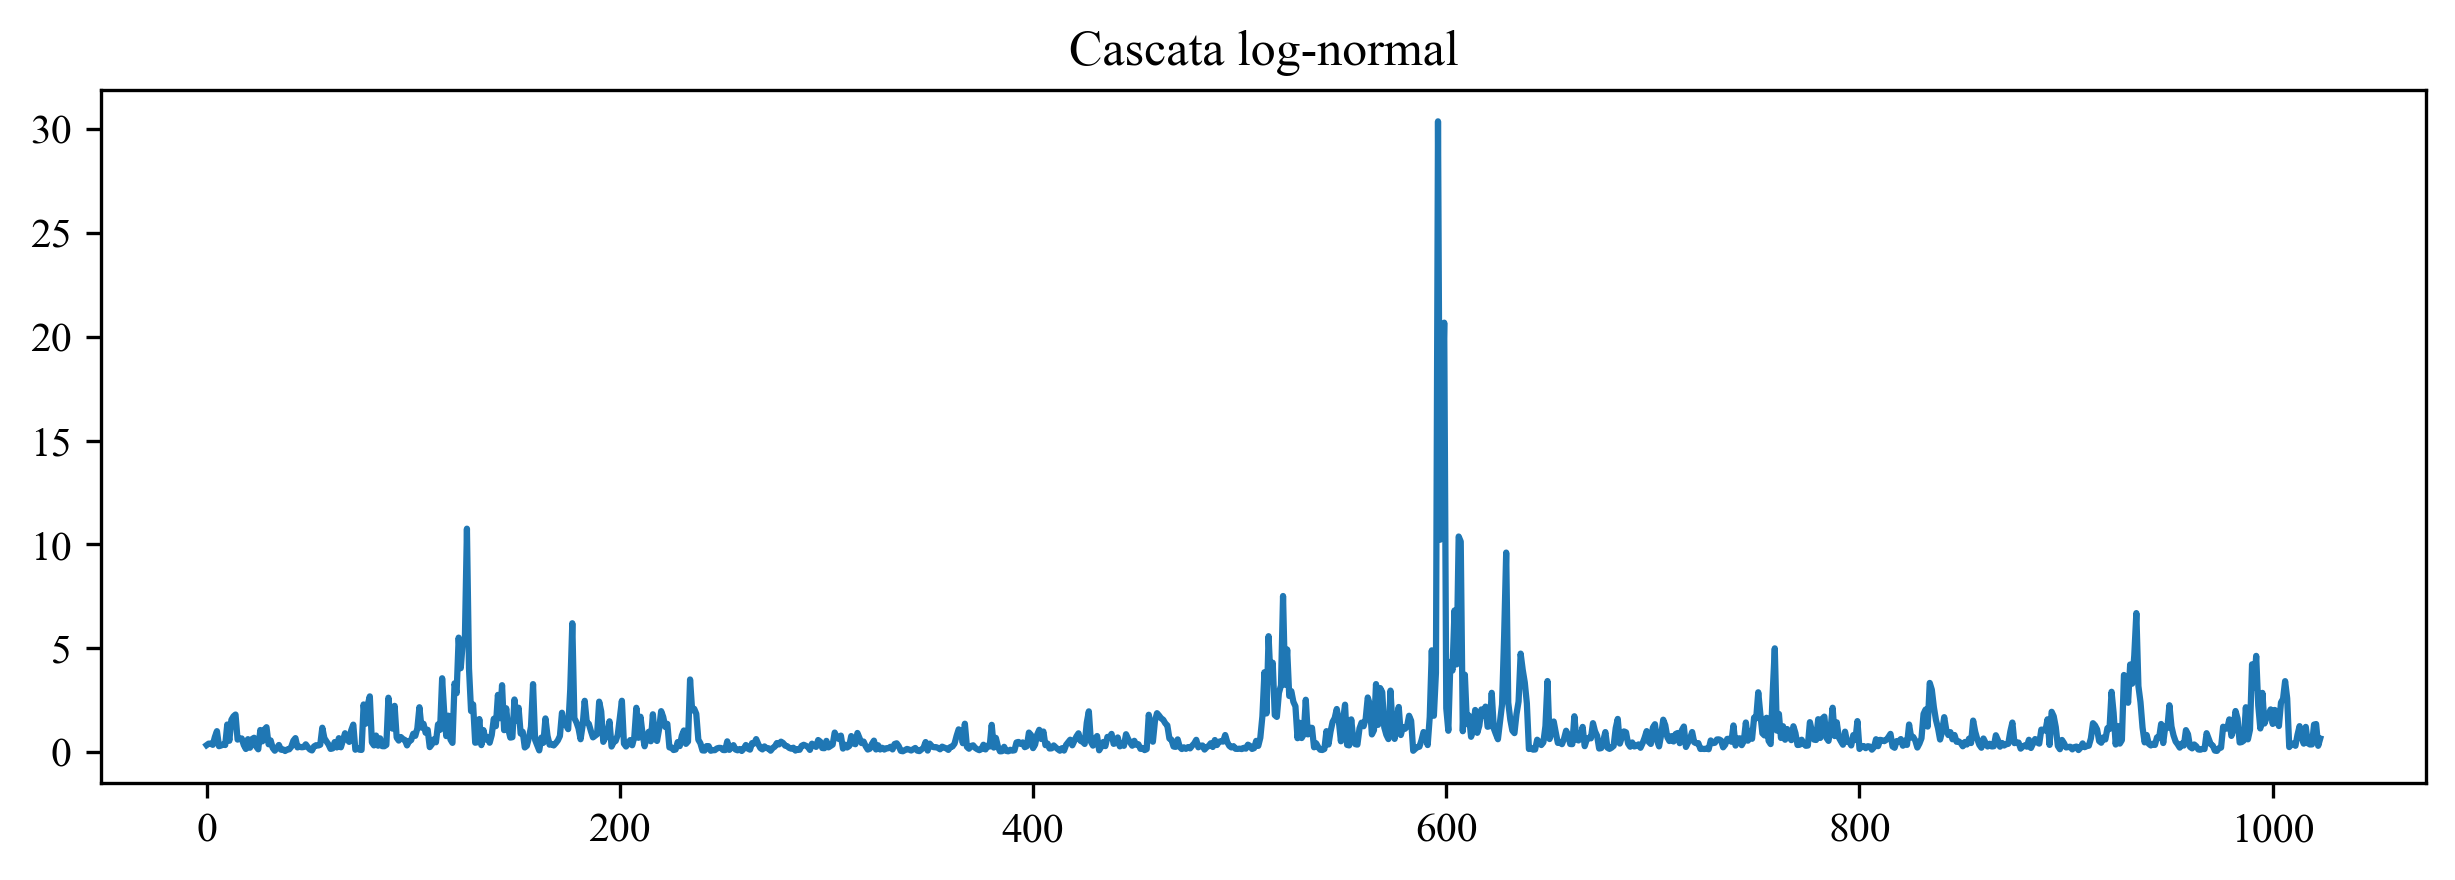

In [34]:
signal_ln = lognormal_cascade(sigma=0.4)

plt.figure(figsize=(10,3))
plt.plot(signal_ln)
plt.title("Cascata log-normal")
plt.show()
